# Chuyên đề 2: BT 2
# 1.  Viết 2 thuật toán để sắp xếp 1 mảng gồm N phần tử (N≤1e5):
a. Dùng giải thuật sắp xếp chèn/nổi bọt.

b. Dùng giải thuật sắp xếp sử dụng cây heap

**Nhóm đã tự viết thuật toán dựa trên lý thuyết về insert sort và heap sort. Trong đó:**
* Insert sort đơn giản là chèn phần tử có giá trị nhỏ trước phần tử có giá trị lớn, tính đến phần tử i đang xét
* Heap sort phức tạp hơn, nhóm triển khai cơ chế max heap ( node cha lớn hơn 2 node con). Vì phải liên tục kiểm tra điều kiện max heap nên đệ quy được sử dụng
* Danh sách N phần tử được đảm bảo giống nhau khi làm input cho 2 giải thuật => dễ đánh giá

In [ ]:
import math
import random 
import time
import matplotlib.pyplot as plt
def insert_sort(list_n):

    time_now = time.time()

    for i in range(1,len(list_n)):
        if list_n[i] < list_n[i-1]:
            a = list_n[i]
            for j in range(i):
                if list_n[i] <= list_n[j] :
                    list_n.insert(j,a)
                    list_n.pop(i+1)

    count = time.time() - time_now 
    return list_n, count


        #         9  [0]
        #     4 [1]      3 [2]
        # 8[3]     10[4]   2[5]    5[6]




# def heap_sort_recursion(list_n, parent_nodes):
#     track_change = 0
#     for i in range(parent_nodes):
#             if list_n[i] < list_n[2*i+1] or list_n[i] < list_n[2*i+2]:
#                 if list_n[2*i+1] < list_n[2*i+2] :
#                     list_n[i], list_n[2*i+2] = list_n[2*i+2], list_n[i]
#                     track_change +=1
#                 else :
#                     list_n[i], list_n[2*i+1] = list_n[2*i+1], list_n[i]
#                     track_change +=1 
#     if track_change  == 0 :
#         return list_n
#     else : 
#         return heap_sort_recursion(list_n,parent_nodes)

def heap_sort_recursion_test(list_n, parent_nodes):
    track_change = 0
    for i in range(parent_nodes):
            try :
                a = list_n[2*i+1]
                
            except IndexError :
               continue
            
            try :
                b = list_n[2*i+2]

            except IndexError :             
                if list_n[i] < a :
                    list_n[i], list_n[2*i+1] = list_n[2*i+1], list_n[i]
                continue

            if list_n[i] < a or list_n[i] < b:
                if list_n[2*i+1] < list_n[2*i+2] :
                    list_n[i], list_n[2*i+2] = list_n[2*i+2], list_n[i]
                    track_change +=1
                else :
                    list_n[i], list_n[2*i+1] = list_n[2*i+1], list_n[i]
                    track_change +=1 
    if track_change  == 0 :
        return list_n
    else : 
        return heap_sort_recursion_test(list_n,parent_nodes)


def heap_sort(list_n):

    a = time.time()
    sorted_list = []
    parent_layers = int(math.log2(len(list_n)))
    parent_nodes = 0
    for i in range(parent_layers):
        parent_nodes  += 2**i


    while len(list_n) > 0 :
        list_n = heap_sort_recursion_test(list_n,parent_nodes)
        sorted_list.insert(0, list_n.pop(0))


    count = time.time() - a
    return sorted_list, count 

if __name__ == "__main__":
    random.seed()
    N = 1
    random_list = []
    random_list.append(random.randint(0,N))


    # for i in range(N):
    #     random_list.append(random.randint(0,N))
    # print(random_list)

    # random_list.append(random.randint(0,N))
    # print(random_list)


    insert_method_time = []
    heap_method_time = []

    while True :
        random_list.append(random.randint(0,N))
        list_copy_for_insert = random_list.copy()
        list_copy_for_heap = random_list.copy()

        insert_method_time.append(insert_sort(list_copy_for_insert)[1])
        heap_method_time.append(heap_sort(list_copy_for_heap)[1])
        N +=1


        if N == 10001:
            break
        elif insert_method_time[N-2] > 5:
            break
        elif heap_method_time[N-2] > 5:
            break

    N_number = [i for i in range(1,N)]
    
    plt.plot(N_number, insert_method_time, label= 'insert_method')
    plt.plot(N_number, heap_method_time, label= 'heap_method')
    plt.legend()
    plt.show()

    # list_heap = [9,4,3,8,10,2,5,5,5]
    # lista = list_heap.copy()
    # listb = list_heap.copy()

    # print(heap_sort(lista))
    # print(insert_sort(listb))  



# 2. Báo cáo thời gian chạy thực (running time) của 2 thuật toán trên khi N tăng dần (N=2,3,...,).
Nếu thời gian chạy >5 s thì xem như "time out" và không cần báo cáo thêm

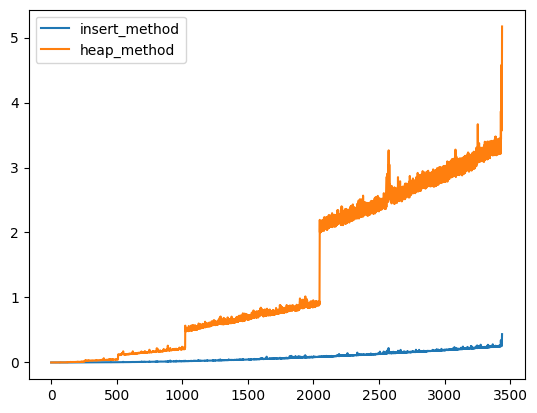

In [4]:
    plt.plot(N_number, insert_method_time, label= 'insert_method')
    plt.plot(N_number, heap_method_time, label= 'heap_method')
    plt.legend()
    plt.show()

**Về tổng quan, khi N tăng dần, heap sort tốn nhiều thời gian hơn insert sort. Tại N=3500, heap sort đã vượt mức 5s, trong khi insert sort chỉ tốn chưa đầy 1s.**
* Lý giải: heap sort được code bằng đệ quy, khi đổi chỗ vị trí các node, đệ quy đảm bảo các node tuân thủ quy tắc max heap. Tuy nhiên, đệ quy là giải thuật cực kỳ cần nhiều running time.
* Insert_sort thì đơn giản hơn, phần tử có giá trị thấp hơn được chèn vào vị trí tính đến phần tử i đang xét => Đơn giản

**Code test thuật toán đã xếp đúng thứ tự bên dưới**

In [5]:
random_list2 = random_list.copy()
random_list2.append(random.randint(0,N))
print(insert_sort(random_list2)[0])


[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 5, 5, 6, 6, 6, 6, 6, 6, 7, 7, 7, 7, 7, 7, 7, 8, 8, 8, 8, 8, 9, 9, 9, 9, 10, 10, 10, 10, 10, 10, 10, 10, 10, 11, 11, 11, 11, 11, 7, 12, 12, 12, 13, 13, 13, 13, 13, 13, 13, 13, 13, 14, 14, 14, 14, 14, 15, 15, 15, 15, 15, 15, 16, 16, 16, 16, 16, 16, 16, 17, 17, 17, 17, 17, 17, 17, 18, 18, 18, 18, 10, 19, 19, 19, 19, 19, 19, 20, 20, 20, 20, 20, 20, 21, 21, 21, 21, 22, 22, 22, 22, 22, 22, 22, 22, 22, 23, 23, 23, 24, 25, 25, 25, 25, 25, 25, 25, 26, 26, 26, 27, 27, 27, 27, 28, 28, 28, 29, 29, 29, 29, 29, 29, 29, 29, 29, 29, 30, 30, 30, 30, 30, 30, 31, 31, 32, 32, 32, 32, 32, 33, 33, 33, 33, 33, 34, 34, 34, 34, 35, 35, 35, 35, 35, 36, 36, 36, 37, 37, 37, 37, 37, 37, 37, 37, 37, 38, 38, 38, 38, 38, 38, 38, 38, 38, 39, 39, 39, 40, 40, 40, 40, 40, 40, 40, 41, 41, 41, 41, 41, 42, 42, 42, 42, 42, 42, 42, 42, 42, 43, 43, 44, 44, 44, 44, 44, 45, 45, 45, 45, 45, 45, 45, 46, 47, 47, 47,

In [6]:
random_list3 = random_list.copy()
random_list3.append(random.randint(0,N))
print(heap_sort(random_list3)[0])


[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 5, 5, 6, 6, 6, 6, 6, 6, 7, 7, 7, 7, 7, 7, 7, 8, 8, 8, 8, 8, 9, 9, 9, 9, 10, 10, 10, 10, 10, 10, 10, 10, 10, 11, 11, 11, 11, 11, 12, 12, 12, 13, 13, 13, 13, 13, 13, 13, 13, 13, 14, 14, 14, 14, 14, 14, 15, 15, 15, 15, 15, 15, 16, 16, 16, 16, 16, 16, 16, 17, 17, 17, 17, 17, 17, 17, 18, 18, 18, 18, 19, 19, 19, 19, 19, 19, 20, 20, 20, 20, 20, 20, 21, 21, 21, 21, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 23, 23, 23, 24, 25, 25, 25, 25, 25, 25, 25, 26, 26, 26, 27, 27, 27, 27, 28, 28, 28, 29, 29, 29, 29, 29, 29, 29, 29, 29, 29, 30, 30, 30, 30, 30, 30, 31, 31, 32, 32, 32, 32, 32, 33, 33, 33, 33, 33, 34, 34, 34, 34, 35, 35, 35, 35, 35, 36, 36, 36, 37, 37, 37, 37, 37, 37, 37, 37, 37, 38, 38, 38, 38, 38, 38, 38, 38, 38, 39, 39, 39, 40, 40, 40, 40, 40, 40, 40, 41, 41, 41, 41, 41, 42, 42, 42, 42, 42, 42, 42, 42, 42, 43, 43, 44, 44, 44, 44, 44, 45, 45, 45, 45, 45, 45, 45, 46, 47, 47, 47

# 3. Kết luận về khả năng chạy của 2 thuật toán 
(N lớn nhất mà thuật toán có thể xử lý được với thời gian thực thi không quá 5s).

In [8]:
print(N)
print(len(heap_method_time))

3438
3437


**Đối với heap sort, max N là 3437**

**Đối với insert sort, max N là: 10395, tuy nhiên random list ở lần chạy này khác so với cell trên nên giá trị này chỉ là tương đối, cụ thể tại link (https://www.kaggle.com/code/trisleevawnminh/chuyen-de-2-bt-2)**

In [ ]:
 while True :
        random_list.append(random.randint(0,N))
     
        list_copy_for_insert = random_list.copy()

        insert_method_time.append(insert_sort(list_copy_for_insert)[1])
        N +=1

        if insert_method_time[N-2] > 5:
            break

print(len(insert_method_time))